# 🔬 RAG Evaluation — Pinecone vs Milvus
### RAGAS metrics comparison on Israeli Cities dataset

This notebook evaluates and compares both RAG backends side-by-side using **RAGAS** — the standard evaluation framework for RAG systems.

**Metrics evaluated:**
| Metric | What it measures |
|--------|-----------------|
| **Faithfulness** | Is the answer grounded in the retrieved context? (hallucination check) |
| **Answer Relevancy** | Does the answer actually address the question? |
| **Context Precision** | Are the retrieved chunks relevant to the question? |
| **Context Recall** | Does the retrieved context contain enough info to answer? |

**Prerequisites:** Both `pinecone.ipynb` and `milvus.ipynb` must have been fully run (data already indexed in both stores).


In [ ]:
! pip install -q ragas pymilvus langchain-milvus langchain-pinecone langchain-openai langchain-classic python-dotenv

## Step 1: Imports & Configuration

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_milvus import Milvus
from langchain_pinecone import PineconeVectorStore
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from pinecone import Pinecone
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

load_dotenv(".env")

# Clear proxy vars if needed
for _var in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy", "NO_PROXY", "no_proxy"):
    os.environ.pop(_var, None)

OPENAI_API_KEY   = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")

# ── Connection settings (must match what was used when indexing) ─────────────
PINECONE_INDEX   = "israel-gov-data"
MILVUS_URI       = "http://localhost:19530"
MILVUS_COLLECTION = "israeli_cities"

embeddings = OpenAIEmbeddings(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
llm        = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=OPENAI_API_KEY)

print("✅ Imports & configuration loaded")
print(f"   OpenAI:   {'✅ set' if OPENAI_API_KEY else '❌ missing'}")
print(f"   Pinecone: {'✅ set' if PINECONE_API_KEY else '❌ missing'}")

c:\Users\hmoshayo\PycharmProjects\AIExperts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hmoshayo\AppData\Local\Temp\ipykernel_33436\1572628292.py:12: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\hmoshayo\AppData\Local\Temp\ipykernel_33436\1572628292.py:12: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\hmoshayo\AppData\Local\Temp\ipykernel_33436\1572628292.py:12: DeprecationWarni

✅ Imports & configuration loaded
   OpenAI:   ✅ set
   Pinecone: ✅ set


## Step 2: Build Both RAG Chains
Connects to the already-indexed data in Pinecone and Milvus (no re-upload needed).

In [2]:
PROMPT = PromptTemplate(
    template="""You are an expert on Israeli cities, towns, and localities.
Use ONLY the context below (from Wikipedia) to answer the question.
If the answer is not in the context, say "I don't have that information in the dataset."

Context:
{context}

Question: {question}

Answer:""",
    input_variables=["context", "question"],
)

# ── Pinecone chain ────────────────────────────────────────────────────────────
pc = Pinecone(api_key=PINECONE_API_KEY)
pinecone_store = PineconeVectorStore(
    index_name=PINECONE_INDEX,
    embedding=embeddings,
    pinecone_api_key=PINECONE_API_KEY,
)
pinecone_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=pinecone_store.as_retriever(search_kwargs={"k": 5}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT},
)

# ── Milvus chain ──────────────────────────────────────────────────────────────
milvus_store = Milvus(
    embedding_function=embeddings,
    collection_name=MILVUS_COLLECTION,
    connection_args={"uri": MILVUS_URI},
)
milvus_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=milvus_store.as_retriever(search_kwargs={"k": 5}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT},
)

print("✅ Both RAG chains ready")

✅ Both RAG chains ready


## Step 3: Evaluation Dataset
A set of questions with ground-truth reference answers. RAGAS uses these to compute **context recall** (does the retrieved context contain enough info to derive the reference answer?).

In [3]:
# Each entry: question + ground-truth reference answer
EVAL_DATASET = [
    {
        "question": "What is Tel Aviv known for?",
        "ground_truth": "Tel Aviv is known as the economic and technological hub of Israel, famous for its vibrant nightlife, beaches, and as a global city.",
    },
    {
        "question": "Where is Haifa located?",
        "ground_truth": "Haifa is located in northern Israel on the slopes of Mount Carmel along the Mediterranean coast.",
    },
    {
        "question": "What is Beer Sheva known as?",
        "ground_truth": "Beer Sheva is known as the capital of the Negev desert and is a major urban center in southern Israel.",
    },
    {
        "question": "When was Petah Tikva founded?",
        "ground_truth": "Petah Tikva was founded in 1878 and is considered one of the first modern Jewish agricultural settlements in the Land of Israel.",
    },
    {
        "question": "What district is Nazareth in?",
        "ground_truth": "Nazareth is located in the Northern District of Israel.",
    },
    {
        "question": "What is Eilat famous for?",
        "ground_truth": "Eilat is famous for its resort hotels, coral reefs, water sports, and as Israel's southernmost city on the Red Sea.",
    },
    {
        "question": "What is the significance of Safed?",
        "ground_truth": "Safed is significant as a historic center of Jewish mysticism and Kabbalah, and is one of Judaism's four holy cities.",
    },
    {
        "question": "What is Bnei Brak known for?",
        "ground_truth": "Bnei Brak is known as a predominantly ultra-Orthodox Jewish city and one of the most densely populated cities in Israel.",
    },
]

print(f"✅ Evaluation dataset ready — {len(EVAL_DATASET)} questions")

✅ Evaluation dataset ready — 8 questions


## Step 4: Run Both Chains Over the Evaluation Dataset

In [4]:
import time

def run_chain(chain, dataset, label):
    """Run a RAG chain over the eval dataset and collect RAGAS-compatible results."""
    records = []
    for i, item in enumerate(dataset, 1):
        q = item["question"]
        print(f"  [{i}/{len(dataset)}] {q[:60]}...")
        t0 = time.time()
        result = chain.invoke({"query": q})
        latency = time.time() - t0
        records.append({
            "question":       q,
            "answer":         result["result"],
            "contexts":       [doc.page_content for doc in result["source_documents"]],
            "ground_truth":   item["ground_truth"],
            "latency_s":      round(latency, 2),
        })
    print(f"✅ {label} done\n")
    return records

print("Running Pinecone chain...")
pinecone_results = run_chain(pinecone_chain, EVAL_DATASET, "Pinecone")

print("Running Milvus chain...")
milvus_results = run_chain(milvus_chain, EVAL_DATASET, "Milvus")

Running Pinecone chain...
  [1/8] What is Tel Aviv known for?...
  [2/8] Where is Haifa located?...
  [3/8] What is Beer Sheva known as?...
  [4/8] When was Petah Tikva founded?...
  [5/8] What district is Nazareth in?...
  [6/8] What is Eilat famous for?...
  [7/8] What is the significance of Safed?...
  [8/8] What is Bnei Brak known for?...
✅ Pinecone done

Running Milvus chain...
  [1/8] What is Tel Aviv known for?...
  [2/8] Where is Haifa located?...
  [3/8] What is Beer Sheva known as?...
  [4/8] When was Petah Tikva founded?...
  [5/8] What district is Nazareth in?...
  [6/8] What is Eilat famous for?...
  [7/8] What is the significance of Safed?...
  [8/8] What is Bnei Brak known for?...
✅ Milvus done



## Step 5: RAGAS Evaluation
Scores each backend on all four RAGAS metrics. This uses the LLM as a judge internally — each call costs a few OpenAI API tokens.

In [5]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Wrap LangChain LLM/embeddings for RAGAS
ragas_llm   = LangchainLLMWrapper(llm)
ragas_emb   = LangchainEmbeddingsWrapper(embeddings)

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]

def ragas_evaluate(results, label):
    ds = Dataset.from_list([
        {
            "question":     r["question"],
            "answer":       r["answer"],
            "contexts":     r["contexts"],
            "ground_truth": r["ground_truth"],
        }
        for r in results
    ])
    print(f"Evaluating {label} with RAGAS...")
    scores = evaluate(
        dataset=ds,
        metrics=METRICS,
        llm=ragas_llm,
        embeddings=ragas_emb,
    )
    return scores.to_pandas()

pinecone_scores = ragas_evaluate(pinecone_results, "Pinecone")
milvus_scores   = ragas_evaluate(milvus_results,   "Milvus")

print("✅ RAGAS evaluation complete")

Evaluating Pinecone with RAGAS...


C:\Users\hmoshayo\AppData\Local\Temp\ipykernel_33436\2202713798.py:5: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm   = LangchainLLMWrapper(llm)
C:\Users\hmoshayo\AppData\Local\Temp\ipykernel_33436\2202713798.py:6: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb   = LangchainEmbeddingsWrapper(embeddings)
Evaluating:   3%|▎         | 1/32 [00:04<02:25,  4.70s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceedin

Evaluating Milvus with RAGAS...


Evaluating:   3%|▎         | 1/32 [00:03<01:38,  3.18s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  53%|█████▎    | 17/32 [00:36<00:20,  1.37s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 32/32 [01:11<00:00,  2.25s/it]


✅ RAGAS evaluation complete


## Step 6: Results — Side-by-Side Comparison

In [6]:
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

# Mean RAGAS scores
summary = pd.DataFrame({
    "Metric":   metric_cols,
    "Pinecone": [pinecone_scores[m].mean() for m in metric_cols],
    "Milvus":   [milvus_scores[m].mean()   for m in metric_cols],
}).set_index("Metric").round(3)

# Mean latency
latency = pd.DataFrame({
    "Backend":        ["Pinecone", "Milvus"],
    "Avg Latency (s)": [
        round(sum(r["latency_s"] for r in pinecone_results) / len(pinecone_results), 2),
        round(sum(r["latency_s"] for r in milvus_results)   / len(milvus_results),   2),
    ],
}).set_index("Backend")

print("=" * 50)
print("         RAGAS SCORES (mean, 0–1, higher = better)")
print("=" * 50)
print(summary.to_string())
print()
print("=" * 50)
print("                  LATENCY")
print("=" * 50)
print(latency.to_string())

         RAGAS SCORES (mean, 0–1, higher = better)
                   Pinecone  Milvus
Metric                             
faithfulness          0.992   1.000
answer_relevancy      0.905   0.931
context_precision     0.875   0.833
context_recall        0.938   0.875

                  LATENCY
          Avg Latency (s)
Backend                  
Pinecone             2.81
Milvus               1.67


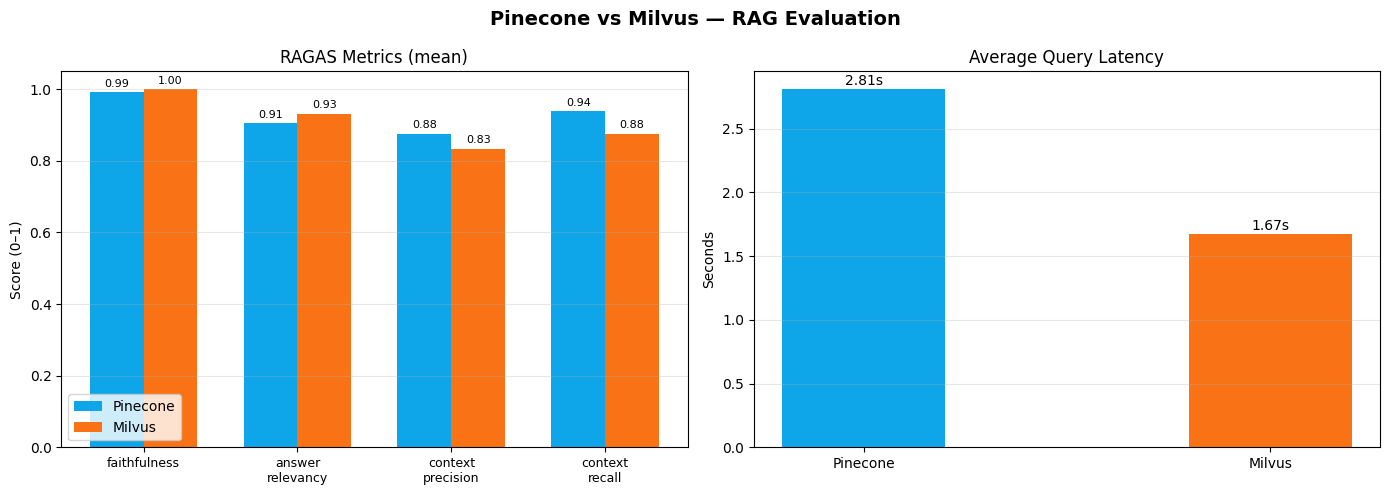

📊 Chart saved to rag_evaluation_results.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pinecone vs Milvus — RAG Evaluation", fontsize=14, fontweight="bold")

# ── Bar chart: RAGAS scores ───────────────────────────────────────────────────
x = np.arange(len(metric_cols))
w = 0.35
ax = axes[0]
ax.bar(x - w/2, summary["Pinecone"], w, label="Pinecone", color="#0ea5e9")
ax.bar(x + w/2, summary["Milvus"],   w, label="Milvus",   color="#f97316")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metric_cols], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (0–1)")
ax.set_title("RAGAS Metrics (mean)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value labels
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
            f"{rect.get_height():.2f}", ha="center", va="bottom", fontsize=8)

# ── Bar chart: latency ────────────────────────────────────────────────────────
ax2 = axes[1]
backends = ["Pinecone", "Milvus"]
lats = [latency.loc[b, "Avg Latency (s)"] for b in backends]
colors = ["#0ea5e9", "#f97316"]
bars = ax2.bar(backends, lats, color=colors, width=0.4)
ax2.set_ylabel("Seconds")
ax2.set_title("Average Query Latency")
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, lats):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}s", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("rag_evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved to rag_evaluation_results.png")